# Test Dashboard Metrics

This notebook is used to validate the business-analysis metrics before connecting them to the app.

Goals:
- inspect derived metrics on one known day
- identify unstable formulas
- test alternative definitions
- inspect outliers and denominator issues
- choose robust metrics for the final dashboard

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

from src.dashboard import (
    load_daily_summary,
    load_hourly_summary,
    load_od_summary,
    load_zone_reference,
)
from src.config import SUPPORTED_DATASETS

C:\Users\Alessio\Desktop\Portfolio_data_analysis\geospatial project\urban_mobility_NYC_geospatial_analysis


In [3]:
dataset = "yellow"
year = 2024
month = 1
day = 15

suffix = f"{dataset}_{year}-{month:02d}-{day:02d}"

trip_path = Path(f"data/processed/daily_trip_data_{suffix}.csv")
daily_path = Path(f"data/processed/daily_zone_summary_{suffix}.csv")
hourly_path = Path(f"data/processed/hourly_zone_summary_{suffix}.csv")
od_path = Path(f"data/processed/od_summary_{suffix}.csv")
zones_path = Path("data/reference/taxi_zones/taxi_zones.shp")

trip_path, daily_path, hourly_path, od_path, zones_path

(WindowsPath('data/processed/daily_trip_data_yellow_2024-01-15.csv'),
 WindowsPath('data/processed/daily_zone_summary_yellow_2024-01-15.csv'),
 WindowsPath('data/processed/hourly_zone_summary_yellow_2024-01-15.csv'),
 WindowsPath('data/processed/od_summary_yellow_2024-01-15.csv'),
 WindowsPath('data/reference/taxi_zones/taxi_zones.shp'))

In [9]:
from src.download import download_parquet_file
from src.preprocess import (
    load_required_trip_data,
    filter_day,
    add_time_columns,
    build_daily_zone_summary,
    build_hourly_zone_summary,
    build_od_summary,
)

# Create a notebook-local cache folder
notebook_cache_dir = PROJECT_ROOT / "notebooks" / "_cache"
notebook_cache_dir.mkdir(parents=True, exist_ok=True)

trip_cache_path = notebook_cache_dir / f"daily_trip_data_{suffix}.csv"
daily_cache_path = notebook_cache_dir / f"daily_zone_summary_{suffix}.csv"
hourly_cache_path = notebook_cache_dir / f"hourly_zone_summary_{suffix}.csv"
od_cache_path = notebook_cache_dir / f"od_summary_{suffix}.csv"

if trip_cache_path.exists() and daily_cache_path.exists() and hourly_cache_path.exists() and od_cache_path.exists():
    print("Loading cached notebook files...")
    trip_df = pd.read_csv(trip_cache_path)
    daily_summary = pd.read_csv(daily_cache_path)
    hourly_summary = pd.read_csv(hourly_cache_path)
    od_summary = pd.read_csv(od_cache_path)
else:
    print("Building notebook test data from source parquet...")

    parquet_path = download_parquet_file(dataset, year, month)

    trip_df = load_required_trip_data(parquet_path, dataset)
    trip_df = filter_day(trip_df, dataset, year, month, day)
    trip_df = add_time_columns(trip_df, dataset)

    daily_summary = build_daily_zone_summary(trip_df, dataset)
    hourly_summary = build_hourly_zone_summary(trip_df, dataset)
    od_summary = build_od_summary(trip_df, dataset)

    trip_df.to_csv(trip_cache_path, index=False)
    daily_summary.to_csv(daily_cache_path, index=False)
    hourly_summary.to_csv(hourly_cache_path, index=False)
    od_summary.to_csv(od_cache_path, index=False)

zones_path = PROJECT_ROOT / "data" / "reference" / "taxi_zones" / "taxi_zones.shp"
zones_path

print("trip_df:", trip_df.shape)
print("daily_summary:", daily_summary.shape)
print("hourly_summary:", hourly_summary.shape)
print("od_summary:", od_summary.shape)
zones_ref = load_zone_reference(zones_path)

print(zones_ref.shape)
zones_ref.head()

trip_df.head()

Loading cached notebook files...
trip_df: (77033, 9)
daily_summary: (216, 6)
hourly_summary: (2236, 6)
od_summary: (5793, 5)
(263, 3)


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount,pickup_hour,pickup_date
0,2024-01-15 00:03:40,2024-01-15 00:08:11,262,140,1.03,7.2,13.42,0,2024-01-15
1,2024-01-15 00:06:52,2024-01-15 00:23:51,163,79,3.14,17.7,27.24,0,2024-01-15
2,2024-01-15 00:00:52,2024-01-15 00:14:06,48,140,2.31,14.2,22.08,0,2024-01-15
3,2024-01-15 00:08:30,2024-01-15 00:23:25,236,7,5.10,21.9,33.84,0,2024-01-15
4,2024-01-15 00:20:03,2024-01-15 00:34:58,138,243,9.36,35.9,52.09,0,2024-01-15


In [11]:
daily_summary.head()

,LocationID,pickup_hour,pickups_count,total_revenue,avg_fare,avg_trip_distance
0,1,5,2,268.10,110.70,0.00
1,1,7,1,90.29,74.24,0.00
2,1,8,1,135.18,96.80,25.87
3,1,12,1,145.20,120.00,0.00
4,1,13,1,137.28,113.40,0.00


In [12]:
hourly_summary.head()

,LocationID,pickup_hour,pickups_count,total_revenue,avg_fare,avg_trip_distance
0,1,5,2,268.10,110.70,0.00
1,1,7,1,90.29,74.24,0.00
2,1,8,1,135.18,96.80,25.87
3,1,12,1,145.20,120.00,0.00
4,1,13,1,137.28,113.40,0.00


In [13]:
print("trip_df columns:")
print(trip_df.columns.tolist())

print("\ndaily_summary columns:")
print(daily_summary.columns.tolist())

print("\nhourly_summary columns:")
print(hourly_summary.columns.tolist())

trip_df columns:
['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount', 'total_amount', 'pickup_hour', 'pickup_date']

daily_summary columns:
['LocationID', 'pickups_count', 'total_revenue', 'avg_fare', 'avg_trip_distance', 'dropoffs_count']

hourly_summary columns:
['LocationID', 'pickup_hour', 'pickups_count', 'total_revenue', 'avg_fare', 'avg_trip_distance']


In [14]:
cfg = SUPPORTED_DATASETS[dataset]

pu_col = cfg["pickup_zone"]
do_col = cfg["dropoff_zone"]
fare_col = cfg["fare_amount"]
total_col = cfg["total_amount"]
distance_col = cfg["trip_distance"]

pu_col, do_col, fare_col, total_col, distance_col

('PULocationID',
 'DOLocationID',
 'fare_amount',
 'total_amount',
 'trip_distance')

In [15]:
trip_test = trip_df.copy()

trip_test = trip_test[trip_test[pu_col].notna()].copy()
trip_test = trip_test[trip_test[distance_col].notna()].copy()
trip_test = trip_test[trip_test[fare_col].notna()].copy()

print(trip_test.shape)
trip_test[[pu_col, fare_col, distance_col]].head()

(77033, 9)


,PULocationID,fare_amount,trip_distance
0,262,7.2,1.03
1,163,17.7,3.14
2,48,14.2,2.31
3,236,21.9,5.10
4,138,35.9,9.36


In [16]:
trip_test[distance_col].describe(percentiles=[0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    77033.000000
mean         3.731492
std          5.065469
min          0.000000
0.1%         0.000000
1%           0.000000
5%           0.450000
10%          0.630000
25%          1.000000
50%          1.700000
75%          3.430000
90%         10.700000
95%         17.310000
99%         20.730000
max         91.730000
Name: trip_distance, dtype: float64

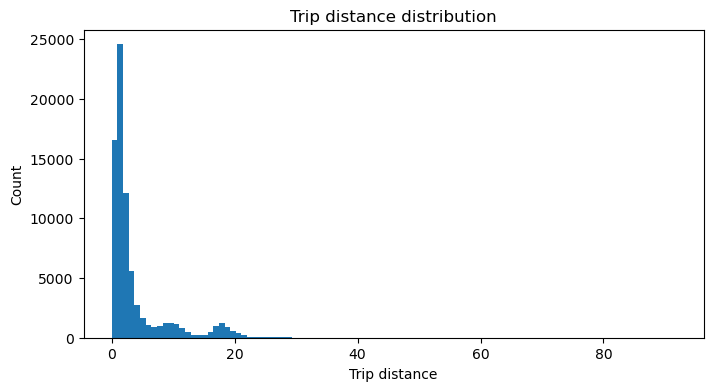

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(trip_test[distance_col], bins=100)
plt.title("Trip distance distribution")
plt.xlabel("Trip distance")
plt.ylabel("Count")
plt.show()

In [18]:
tiny_distance = trip_test[trip_test[distance_col] < 0.5].copy()
print(tiny_distance.shape)
tiny_distance[[pu_col, fare_col, distance_col]].head(20)

(4358, 9)


,PULocationID,fare_amount,trip_distance
36,249,5.10,0.37
54,132,4.40,0.11
86,162,-3.00,0.00
87,162,3.00,0.00
104,88,37.95,0.00
105,100,5.10,0.40
108,230,3.70,0.00
142,144,5.10,0.30
159,233,-3.00,0.03
160,233,3.00,0.03


In [19]:
trip_test = trip_test[trip_test[distance_col] > 0].copy()
trip_test["fare_per_distance_trip"] = trip_test[fare_col] / trip_test[distance_col]

trip_test["fare_per_distance_trip"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    75620.000000
mean        10.617051
std        169.846308
min      -7000.000000
1%          -3.721699
5%           3.825137
10%          4.060343
25%          5.350000
50%          6.739663
75%          8.349515
90%         10.357143
95%         12.100000
99%         18.571429
max       8769.000000
Name: fare_per_distance_trip, dtype: float64

## Evidence 1:
There are no charge/dispute/voided as invalid entries for our analysis. We now remove them 

In [21]:
trip_test = trip_test[trip_test[fare_col] > 0].copy()
trip_test["fare_per_distance_trip"] = trip_test[fare_col] / trip_test[distance_col]

trip_test["fare_per_distance_trip"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    74789.000000
mean        11.951123
std        152.273398
min          0.010870
1%           3.447345
5%           3.884573
10%          4.109436
25%          5.405405
50%          6.772152
75%          8.372093
90%         10.388350
95%         12.142857
99%         18.625789
max       8769.000000
Name: fare_per_distance_trip, dtype: float64

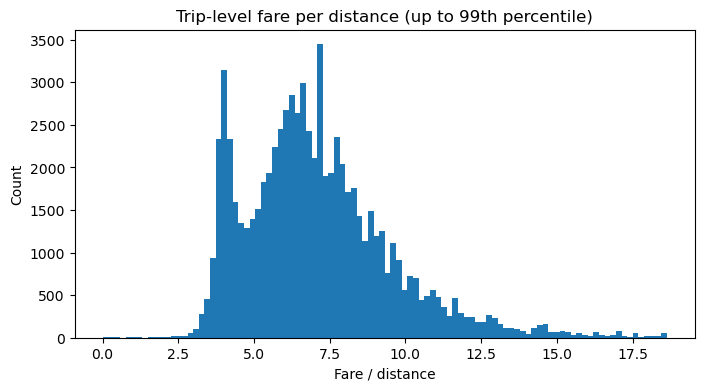

In [38]:
q99 = trip_test["fare_per_distance_trip"].quantile(0.99)
plot_data = trip_test.loc[
    trip_test["fare_per_distance_trip"] <= q99,
    "fare_per_distance_trip"
]

plt.figure(figsize=(8, 4))
plt.hist(plot_data, bins=100)
plt.title("Trip-level fare per distance (up to 99th percentile)")
plt.xlabel("Fare / distance")
plt.ylabel("Count")
plt.show()

In [40]:
#Worst outliers
trip_test.sort_values("fare_per_distance_trip", ascending=False)[
    [pu_col, fare_col, distance_col, "fare_per_distance_trip"]
].head(50)

,PULocationID,fare_amount,trip_distance,fare_per_distance_trip
73295,87,87.69,0.01,8769.000000
43178,75,87.69,0.01,8769.000000
1445,116,87.00,0.01,8700.000000
61853,170,87.00,0.01,8700.000000
36094,249,86.00,0.01,8600.000000
71978,161,85.25,0.01,8525.000000
9015,233,82.69,0.01,8269.000000
46018,132,81.69,0.01,8169.000000
34971,132,79.00,0.01,7900.000000
10825,164,78.75,0.01,7875.000000


In [25]:
zone_lookup = zones_ref.rename(columns={"LocationID": pu_col, "zone": "pickup_zone_name", "borough": "pickup_borough"})
trip_test_named = trip_test.merge(zone_lookup[[pu_col, "pickup_zone_name", "pickup_borough"]], on=pu_col, how="left")

trip_test_named.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount,pickup_hour,pickup_date,fare_per_distance_trip,pickup_zone_name,pickup_borough
0,2024-01-15 00:03:40,2024-01-15 00:08:11,262,140,1.03,7.2,13.42,0,2024-01-15,6.990291,Yorkville East,Manhattan
1,2024-01-15 00:06:52,2024-01-15 00:23:51,163,79,3.14,17.7,27.24,0,2024-01-15,5.636943,Midtown North,Manhattan
2,2024-01-15 00:00:52,2024-01-15 00:14:06,48,140,2.31,14.2,22.08,0,2024-01-15,6.147186,Clinton East,Manhattan
3,2024-01-15 00:08:30,2024-01-15 00:23:25,236,7,5.10,21.9,33.84,0,2024-01-15,4.294118,Upper East Side North,Manhattan
4,2024-01-15 00:20:03,2024-01-15 00:34:58,138,243,9.36,35.9,52.09,0,2024-01-15,3.835470,LaGuardia Airport,Queens


In [26]:
suspicious_zone = "Hamilton Heights"

zone_rows = trip_test_named[trip_test_named["pickup_zone_name"] == suspicious_zone].copy()
print(zone_rows.shape)

zone_rows[[fare_col, distance_col, "fare_per_distance_trip"]].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

(38, 12)


,fare_amount,trip_distance,fare_per_distance_trip
count,38.000000,38.000000,38.000000
mean,23.135526,4.148158,235.016560
std,15.303208,2.992384,1410.318463
min,3.700000,0.010000,3.460613
1%,4.995000,0.069200,3.562285
5%,8.985000,0.680000,3.918787
10%,9.300000,1.098000,4.161756
25%,12.800000,1.825000,4.487419
50%,19.985000,3.550000,5.676740
75%,27.500000,6.045000,6.750000


In [27]:
zone_rows.sort_values("fare_per_distance_trip", ascending=False)[
    ["pickup_zone_name", fare_col, distance_col, "fare_per_distance_trip"]
].head(20)

,pickup_zone_name,fare_amount,trip_distance,fare_per_distance_trip
1411,Hamilton Heights,87.0,0.01,8700.000000
2774,Hamilton Heights,3.7,0.17,21.764706
41022,Hamilton Heights,18.5,1.90,9.736842
42956,Hamilton Heights,7.2,0.77,9.350649
19820,Hamilton Heights,9.3,1.00,9.300000
18222,Hamilton Heights,9.3,1.14,8.157895
64740,Hamilton Heights,13.5,1.80,7.500000
15543,Hamilton Heights,19.5,2.60,7.500000
4461,Hamilton Heights,17.0,2.50,6.800000
31743,Hamilton Heights,11.4,1.68,6.785714


In [28]:
zone_ratio_mean = (
    trip_test_named.groupby([pu_col, "pickup_zone_name", "pickup_borough"], as_index=False)
    .agg(
        pickups_count=(pu_col, "size"),
        avg_fare=(fare_col, "mean"),
        avg_trip_distance=(distance_col, "mean"),
        fare_per_distance_mean=("fare_per_distance_trip", "mean"),
    )
    .sort_values("fare_per_distance_mean", ascending=False)
)

zone_ratio_mean.head(20)

,PULocationID,pickup_zone_name,pickup_borough,pickups_count,avg_fare,avg_trip_distance,fare_per_distance_mean
103,135,Kew Gardens Hills,Queens,2,20.750000,0.455000,1753.611111
102,134,Kew Gardens,Queens,4,60.700000,4.857500,1095.167334
91,120,Highbridge Park,Manhattan,1,85.000000,0.080000,1062.500000
150,194,Randalls Island,Manhattan,6,66.260000,2.238333,699.383291
65,80,East Williamsburg,Brooklyn,6,41.316667,1.461667,597.817861
20,26,Borough Park,Brooklyn,5,25.592000,4.058000,401.981078
111,145,Long Island City/Hunters Point,Queens,42,41.118095,3.940714,242.444373
88,116,Hamilton Heights,Manhattan,38,23.135526,4.148158,235.016560
98,129,Jackson Heights,Queens,17,39.070588,5.241765,138.417534
49,64,Douglaston,Queens,2,51.810000,5.760000,131.123852


In [29]:
zone_ratio_stable = (
    trip_test_named.groupby([pu_col, "pickup_zone_name", "pickup_borough"], as_index=False)
    .agg(
        pickups_count=(pu_col, "size"),
        total_fare=(fare_col, "sum"),
        total_distance=(distance_col, "sum"),
        avg_fare=(fare_col, "mean"),
        avg_trip_distance=(distance_col, "mean"),
    )
)

zone_ratio_stable["fare_per_distance_grouped"] = (
    zone_ratio_stable["total_fare"] / zone_ratio_stable["total_distance"]
)

zone_ratio_stable = zone_ratio_stable.sort_values("fare_per_distance_grouped", ascending=False)

zone_ratio_stable.head(20)

,PULocationID,pickup_zone_name,pickup_borough,pickups_count,total_fare,total_distance,avg_fare,avg_trip_distance,fare_per_distance_grouped
91,120,Highbridge Park,Manhattan,1,85.00,0.08,85.000000,0.080000,1062.500000
158,207,Saint Michaels Cemetery/Woodside,Queens,1,120.00,2.56,120.000000,2.560000,46.875000
103,135,Kew Gardens Hills,Queens,2,41.50,0.91,20.750000,0.455000,45.604396
150,194,Randalls Island,Manhattan,6,397.56,13.43,66.260000,2.238333,29.602383
65,80,East Williamsburg,Brooklyn,6,247.90,8.77,41.316667,1.461667,28.266819
68,83,Elmhurst/Maspeth,Queens,6,182.26,14.09,30.376667,2.348333,12.935415
102,134,Kew Gardens,Queens,4,242.80,19.43,60.700000,4.857500,12.496140
111,145,Long Island City/Hunters Point,Queens,42,1726.96,165.51,41.118095,3.940714,10.434173
132,167,Morrisania/Melrose,Bronx,1,46.50,4.60,46.500000,4.600000,10.108696
203,260,Woodside,Queens,22,686.48,69.58,31.203636,3.162727,9.866053


In [30]:
zone_compare = zone_ratio_mean.merge(
    zone_ratio_stable[
        [pu_col, "fare_per_distance_grouped"]
    ],
    on=pu_col,
    how="left"
)

zone_compare[
    [
        "pickup_zone_name",
        "pickup_borough",
        "pickups_count",
        "avg_fare",
        "avg_trip_distance",
        "fare_per_distance_mean",
        "fare_per_distance_grouped",
    ]
].head(20)

,pickup_zone_name,pickup_borough,pickups_count,avg_fare,avg_trip_distance,fare_per_distance_mean,fare_per_distance_grouped
0,Kew Gardens Hills,Queens,2,20.750000,0.455000,1753.611111,45.604396
1,Kew Gardens,Queens,4,60.700000,4.857500,1095.167334,12.496140
2,Highbridge Park,Manhattan,1,85.000000,0.080000,1062.500000,1062.500000
3,Randalls Island,Manhattan,6,66.260000,2.238333,699.383291,29.602383
4,East Williamsburg,Brooklyn,6,41.316667,1.461667,597.817861,28.266819
5,Borough Park,Brooklyn,5,25.592000,4.058000,401.981078,6.306555
6,Long Island City/Hunters Point,Queens,42,41.118095,3.940714,242.444373,10.434173
7,Hamilton Heights,Manhattan,38,23.135526,4.148158,235.016560,5.577301
8,Jackson Heights,Queens,17,39.070588,5.241765,138.417534,7.453709
9,Douglaston,Queens,2,51.810000,5.760000,131.123852,8.994792


In [31]:
zone_ratio_filtered = zone_ratio_stable[
    (zone_ratio_stable["pickups_count"] >= 10) &
    (zone_ratio_stable["avg_trip_distance"] >= 1.0)
].copy()

zone_ratio_filtered.sort_values("fare_per_distance_grouped", ascending=False).head(20)

,PULocationID,pickup_zone_name,pickup_borough,pickups_count,total_fare,total_distance,avg_fare,avg_trip_distance,fare_per_distance_grouped
111,145,Long Island City/Hunters Point,Queens,42,1726.96,165.51,41.118095,3.940714,10.434173
203,260,Woodside,Queens,22,686.48,69.58,31.203636,3.162727,9.866053
166,216,South Ozone Park,Queens,25,1317.89,133.75,52.715600,5.350000,9.853383
44,56,Corona,Queens,20,936.34,117.70,46.817000,5.885000,7.955310
98,129,Jackson Heights,Queens,17,664.20,89.11,39.070588,5.241765,7.453709
193,246,West Chelsea/Hudson Yards,Manhattan,2431,37048.17,5544.00,15.239889,2.280543,6.682570
186,237,Upper East Side South,Manhattan,3383,40350.13,6113.50,11.927322,1.807124,6.600168
144,186,Penn Station/Madison Sq West,Manhattan,3320,50528.58,7745.19,15.219452,2.332889,6.523866
77,93,Flushing Meadows-Corona Park,Queens,17,1104.29,169.99,64.958235,9.999412,6.496206
86,113,Greenwich Village North,Manhattan,940,12185.16,1894.89,12.962936,2.015840,6.430537


In [32]:
trip_hour = trip_test.copy()

pickup_datetime_col = cfg["pickup_datetime"]
trip_hour[pickup_datetime_col] = pd.to_datetime(trip_hour[pickup_datetime_col], errors="coerce")
trip_hour = trip_hour.dropna(subset=[pickup_datetime_col]).copy()
trip_hour["pickup_hour"] = trip_hour[pickup_datetime_col].dt.hour

hour_ratio = (
    trip_hour.groupby("pickup_hour", as_index=False)
    .agg(
        pickups_count=("pickup_hour", "size"),
        total_fare=(fare_col, "sum"),
        total_distance=(distance_col, "sum"),
    )
)

hour_ratio["fare_per_distance_grouped"] = hour_ratio["total_fare"] / hour_ratio["total_distance"]

hour_ratio

,pickup_hour,pickups_count,total_fare,total_distance,fare_per_distance_grouped
0,0,2163,48246.87,10062.16,4.794882
1,1,1041,19584.16,4098.75,4.778081
2,2,712,13604.99,2821.74,4.821490
3,3,411,8490.82,1718.61,4.940516
4,4,335,9684.27,2095.82,4.620755
5,5,450,14518.12,3402.64,4.266722
6,6,873,24159.38,5380.67,4.490032
7,7,1325,29519.31,6302.36,4.683850
8,8,2364,42380.21,8111.05,5.224997
9,9,3013,53424.09,10098.99,5.290043


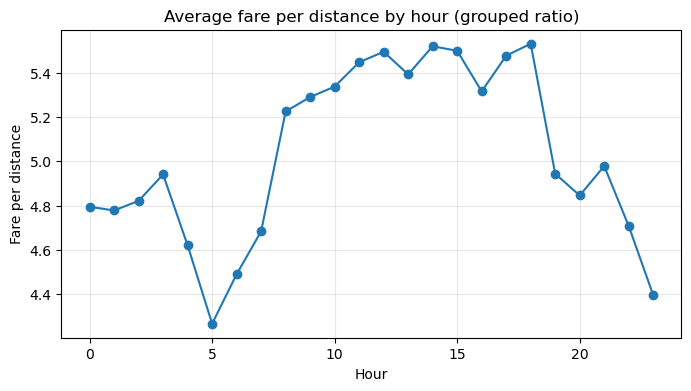

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(hour_ratio["pickup_hour"], hour_ratio["fare_per_distance_grouped"], marker="o")
plt.title("Average fare per distance by hour (grouped ratio)")
plt.xlabel("Hour")
plt.ylabel("Fare per distance")
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
trip_borough = trip_test_named.dropna(subset=["pickup_borough"]).copy()

borough_ratio = (
    trip_borough.groupby("pickup_borough", as_index=False)
    .agg(
        pickups_count=(pu_col, "size"),
        total_fare=(fare_col, "sum"),
        total_distance=(distance_col, "sum"),
    )
)

borough_ratio["fare_per_distance_grouped"] = borough_ratio["total_fare"] / borough_ratio["total_distance"]

borough_ratio.sort_values("fare_per_distance_grouped", ascending=False)

,pickup_borough,pickups_count,total_fare,total_distance,fare_per_distance_grouped
3,Manhattan,64210,920958.08,150497.36,6.119430
2,EWR,2,244.00,45.46,5.367356
5,Staten Island,1,75.00,15.70,4.777070
1,Brooklyn,413,12418.03,2605.85,4.765443
0,Bronx,74,2479.92,579.16,4.281926
4,Queens,9792,524903.62,128978.38,4.069702


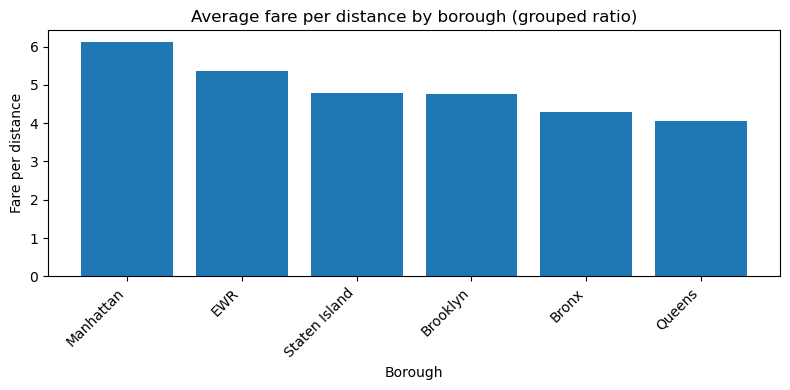

In [35]:
borough_plot = borough_ratio.sort_values("fare_per_distance_grouped", ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(borough_plot["pickup_borough"], borough_plot["fare_per_distance_grouped"])
plt.title("Average fare per distance by borough (grouped ratio)")
plt.xlabel("Borough")
plt.ylabel("Fare per distance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [36]:
borough_share = (
    trip_borough.groupby("pickup_borough", as_index=False)
    .agg(
        total_pickups=(pu_col, "size"),
        total_revenue=(total_col, "sum"),
    )
)

borough_share["pickup_share"] = borough_share["total_pickups"] / borough_share["total_pickups"].sum()
borough_share["revenue_share"] = borough_share["total_revenue"] / borough_share["total_revenue"].sum()
borough_share["revenue_share_vs_pickup_share"] = borough_share["revenue_share"] / borough_share["pickup_share"]

borough_share.sort_values("revenue_share_vs_pickup_share", ascending=False)

,pickup_borough,total_pickups,total_revenue,pickup_share,revenue_share,revenue_share_vs_pickup_share
2,EWR,2,332.68,0.000027,0.000156,5.811211
5,Staten Island,1,115.66,0.000013,0.000054,4.040668
4,Queens,9792,717880.86,0.131450,0.336676,2.561244
0,Bronx,74,2794.42,0.000993,0.001311,1.319259
1,Brooklyn,413,14714.82,0.005544,0.006901,1.244729
3,Manhattan,64210,1396419.24,0.861972,0.654902,0.759772


In [41]:
#check shorter distances, to see if they all all pathologic

shortest_cols = [pu_col, fare_col, distance_col]
if "pickup_hour" in trip_test.columns:
    shortest_cols.append("pickup_hour")

trip_test.sort_values(distance_col, ascending=True)[shortest_cols].head(50)

short_distance_check = trip_test.copy()
short_distance_check = short_distance_check[short_distance_check[distance_col] > 0].copy()
short_distance_check["fare_per_distance_trip"] = (
    short_distance_check[fare_col] / short_distance_check[distance_col]
)

cols = [pu_col, fare_col, distance_col, "fare_per_distance_trip"]
if "pickup_hour" in short_distance_check.columns:
    cols.append("pickup_hour")

short_distance_check.sort_values(distance_col, ascending=True)[cols].head(50)

,PULocationID,fare_amount,trip_distance,fare_per_distance_trip,pickup_hour
51938,68,3.00,0.01,300.0,17
59177,230,3.00,0.01,300.0,19
69703,230,3.00,0.01,300.0,22
32047,237,3.00,0.01,300.0,14
3905,142,70.00,0.01,7000.0,3
69402,162,70.00,0.01,7000.0,21
52334,230,70.00,0.01,7000.0,17
35582,132,3.00,0.01,300.0,14
46496,90,3.00,0.01,300.0,16
28393,234,3.70,0.01,370.0,13


In [42]:
zone_lookup = zones_ref.rename(
    columns={
        "LocationID": pu_col,
        "zone": "pickup_zone_name",
        "borough": "pickup_borough",
    }
)

short_distance_named = trip_test.merge(
    zone_lookup[[pu_col, "pickup_zone_name", "pickup_borough"]],
    on=pu_col,
    how="left",
)

short_distance_named = short_distance_named[short_distance_named[distance_col] > 0].copy()
short_distance_named["fare_per_distance_trip"] = (
    short_distance_named[fare_col] / short_distance_named[distance_col]
)

short_distance_named[
    [
        "pickup_zone_name",
        "pickup_borough",
        fare_col,
        distance_col,
        "fare_per_distance_trip",
    ]
].sort_values(distance_col, ascending=True).head(50)

,pickup_zone_name,pickup_borough,fare_amount,trip_distance,fare_per_distance_trip
44481,JFK Airport,Queens,3.00,0.01,300.0
46310,NaN,NaN,3.00,0.01,300.0
41304,JFK Airport,Queens,3.00,0.01,300.0
71494,Financial District North,Manhattan,87.69,0.01,8769.0
8894,World Trade Center,Manhattan,3.70,0.01,370.0
24384,East Chelsea,Manhattan,70.00,0.01,7000.0
21456,JFK Airport,Queens,70.00,0.01,7000.0
1411,Hamilton Heights,Manhattan,87.00,0.01,8700.0
57721,Times Sq/Theatre District,Manhattan,3.00,0.01,300.0
25604,Queensbridge/Ravenswood,Queens,3.00,0.01,300.0


In [43]:
base_df = trip_test.copy()

base_df = base_df[base_df[fare_col] > 0].copy()
base_df = base_df[base_df[distance_col] > 0].copy()

base_df["fare_per_distance_trip"] = base_df[fare_col] / base_df[distance_col]

print(base_df.shape)
base_df[[fare_col, distance_col, "fare_per_distance_trip"]].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

thresholds = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

rows = []

for t in thresholds:
    subset = base_df[base_df[distance_col] >= t].copy()
    if len(subset) == 0:
        continue

    rows.append(
        {
            "min_distance": t,
            "n_trips": len(subset),
            "mean_fare_per_distance": subset["fare_per_distance_trip"].mean(),
            "median_fare_per_distance": subset["fare_per_distance_trip"].median(),
            "p95_fare_per_distance": subset["fare_per_distance_trip"].quantile(0.95),
            "p99_fare_per_distance": subset["fare_per_distance_trip"].quantile(0.99),
            "max_fare_per_distance": subset["fare_per_distance_trip"].max(),
        }
    )

threshold_summary = pd.DataFrame(rows)
threshold_summary

(74789, 10)


,min_distance,n_trips,mean_fare_per_distance,median_fare_per_distance,p95_fare_per_distance,p99_fare_per_distance,max_fare_per_distance
0,0.01,74789,11.951123,6.772152,12.142857,18.625789,8769.000000
1,0.05,74651,7.928171,6.769231,12.000000,17.619048,1746.000000
2,0.10,74590,7.500608,6.761905,12.000000,17.222222,1558.181818
3,0.25,74305,7.227637,6.752137,11.818182,16.060435,554.285714
4,0.50,71980,6.971135,6.686052,10.875912,14.285714,554.285714
5,1.00,57947,6.276615,6.220472,9.174312,11.636364,133.333333


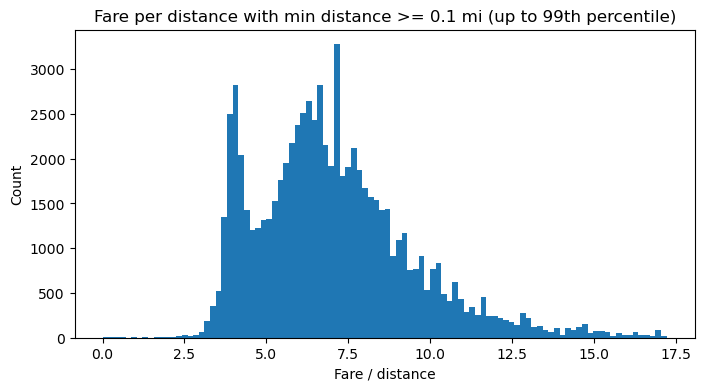

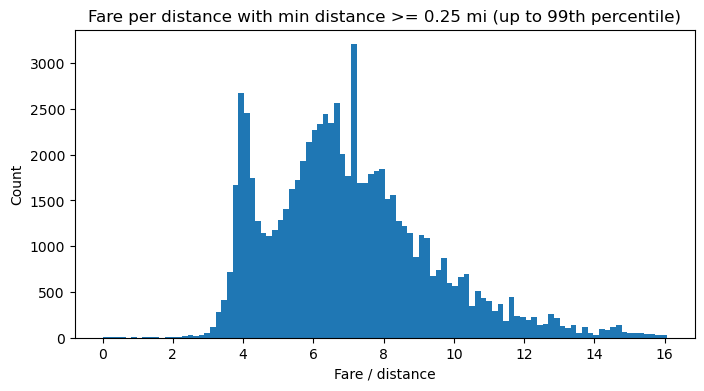

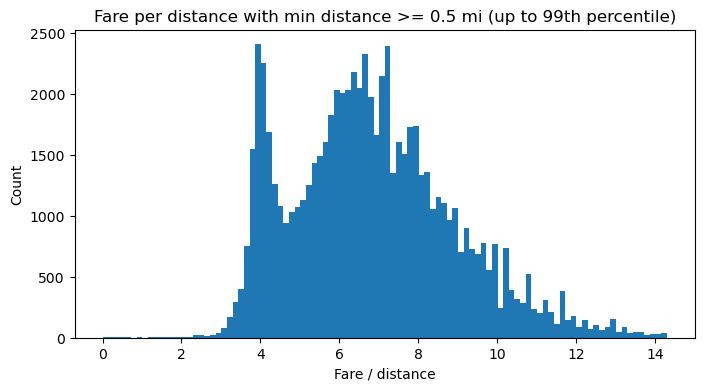

In [44]:
for t in [0.10, 0.25, 0.50]:
    subset = base_df[base_df[distance_col] >= t].copy()
    q99 = subset["fare_per_distance_trip"].quantile(0.99)
    plot_data = subset.loc[subset["fare_per_distance_trip"] <= q99, "fare_per_distance_trip"]

    plt.figure(figsize=(8, 4))
    plt.hist(plot_data, bins=100)
    plt.title(f"Fare per distance with min distance >= {t} mi (up to 99th percentile)")
    plt.xlabel("Fare / distance")
    plt.ylabel("Count")
    plt.show()

## Test filters

In [59]:
filtered_df = trip_test.copy()

filtered_df = filtered_df[filtered_df[fare_col] > 0].copy()
filtered_df = filtered_df[filtered_df[distance_col] >= 0.25].copy()

filtered_df["fare_per_distance_trip"] = (
    filtered_df[fare_col] / filtered_df[distance_col]
)

filtered_df = filtered_df[filtered_df["fare_per_distance_trip"] <= 100].copy()

print(filtered_df.shape)
filtered_df["fare_per_distance_trip"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

zone_metric_filtered = (
    filtered_df.groupby(pu_col, as_index=False)
    .agg(
        pickups_count=(pu_col, "size"),
        avg_fare=(fare_col, "mean"),
        avg_trip_distance=(distance_col, "mean"),
        fare_per_distance=("fare_per_distance_trip", "mean"),
    )
)

zone_metric_filtered = zone_metric_filtered[
    zone_metric_filtered["pickups_count"] >= 10
].copy()

(74282, 10)


In [60]:
comparison = pd.DataFrame({
    "version": ["raw", "filtered"],
    "n_trips": [len(trip_test), len(filtered_df)],
    "mean_fare_per_distance": [
        trip_test["fare_per_distance_trip"].mean(),
        filtered_df["fare_per_distance_trip"].mean(),
    ],
    "median_fare_per_distance": [
        trip_test["fare_per_distance_trip"].median(),
        filtered_df["fare_per_distance_trip"].median(),
    ],
    "p95_fare_per_distance": [
        trip_test["fare_per_distance_trip"].quantile(0.95),
        filtered_df["fare_per_distance_trip"].quantile(0.95),
    ],
    "p99_fare_per_distance": [
        trip_test["fare_per_distance_trip"].quantile(0.99),
        filtered_df["fare_per_distance_trip"].quantile(0.99),
    ],
    "max_fare_per_distance": [
        trip_test["fare_per_distance_trip"].max(),
        filtered_df["fare_per_distance_trip"].max(),
    ],
})

comparison

,version,n_trips,mean_fare_per_distance,median_fare_per_distance,p95_fare_per_distance,p99_fare_per_distance,max_fare_per_distance
0,raw,74789,11.951123,6.772152,12.142857,18.625789,8769.0
1,filtered,74282,7.161190,6.752137,11.803279,15.928125,100.0


In [61]:
zone_lookup = zones_ref.rename(
    columns={
        "LocationID": pu_col,
        "zone": "pickup_zone_name",
        "borough": "pickup_borough",
    }
)

zone_metric_filtered = filtered_df.merge(
    zone_lookup[[pu_col, "pickup_zone_name", "pickup_borough"]],
    on=pu_col,
    how="left",
)

zone_metric_filtered = (
    zone_metric_filtered.groupby(
        ["pickup_zone_name", "pickup_borough"], as_index=False
    )
    .agg(
        pickups_count=(pu_col, "size"),
        avg_fare=(fare_col, "mean"),
        avg_trip_distance=(distance_col, "mean"),
        fare_per_distance=("fare_per_distance_trip", "mean"),
    )
)

zone_metric_filtered = zone_metric_filtered[
    zone_metric_filtered["pickups_count"] >= 10
].copy()

zone_metric_filtered.sort_values("fare_per_distance", ascending=False).head(20)

,pickup_zone_name,pickup_borough,pickups_count,avg_fare,avg_trip_distance,fare_per_distance
97,Jackson Heights,Queens,15,34.646667,5.921333,17.539872
109,Long Island City/Hunters Point,Queens,37,37.553514,4.465676,11.698680
165,South Ozone Park,Queens,20,50.898500,6.653000,11.585649
131,Mott Haven/Port Morris,Bronx,10,27.567000,5.828000,10.667990
80,Garment District,Manhattan,1292,14.652972,2.319002,8.419241
202,Woodside,Queens,20,25.197500,3.454000,8.358576
36,Clinton Hill,Brooklyn,13,34.357692,6.226154,8.223291
192,West Chelsea/Hudson Yards,Manhattan,2420,15.265525,2.290393,8.103873
185,Upper East Side South,Manhattan,3364,11.948374,1.816323,8.007585
35,Clinton East,Manhattan,2029,13.932316,2.295983,7.990983


In [62]:
zone_metric_filtered[
    zone_metric_filtered["pickup_zone_name"].isin(["Hamilton Heights", "Newark Airport"])
].sort_values("fare_per_distance", ascending=False)

,pickup_zone_name,pickup_borough,pickups_count,avg_fare,avg_trip_distance,fare_per_distance
87,Hamilton Heights,Manhattan,36,21.901389,4.373611,5.801793


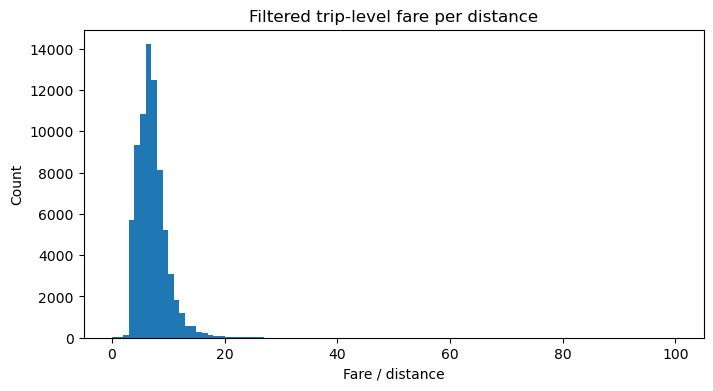

In [63]:
plt.figure(figsize=(8, 4))
plt.hist(filtered_df["fare_per_distance_trip"], bins=100)
plt.title("Filtered trip-level fare per distance")
plt.xlabel("Fare / distance")
plt.ylabel("Count")
plt.show()

In [64]:
filtered_df.sort_values(
    "fare_per_distance_trip",
    ascending=False
)[
    [pu_col, fare_col, distance_col, "fare_per_distance_trip"]
].head(100)

,PULocationID,fare_amount,trip_distance,fare_per_distance_trip
4976,129,70.0,0.70,100.000000
16142,22,57.5,0.60,95.833333
57900,138,60.0,0.63,95.238095
22886,151,70.0,0.75,93.333333
9914,145,86.0,0.93,92.473118
...,...,...,...,...
34183,164,8.6,0.33,26.060606
45789,234,6.5,0.25,26.000000
8404,68,9.3,0.36,25.833333
29809,95,15.5,0.60,25.833333


In [58]:
zone_lookup = zones_ref.rename(
    columns={
        "LocationID": pu_col,
        "zone": "pickup_zone_name",
        "borough": "pickup_borough",
    }
)

zone_metric_filtered = filtered_df.merge(
    zone_lookup[[pu_col, "pickup_zone_name", "pickup_borough"]],
    on=pu_col,
    how="left",
)

zone_metric_filtered = (
    zone_metric_filtered.groupby(
        ["pickup_zone_name", "pickup_borough"], as_index=False
    )
    .agg(
        pickups_count=(pu_col, "size"),
        avg_fare=(fare_col, "mean"),
        avg_trip_distance=(distance_col, "mean"),
        mean_fare_per_distance=("fare_per_distance_trip", "mean"),
    )
)

zone_metric_filtered = zone_metric_filtered[
    zone_metric_filtered["pickups_count"] >= 10
].copy()

zone_metric_filtered = zone_metric_filtered.sort_values(
    "mean_fare_per_distance",
    ascending=False
).reset_index(drop=True)

zone_metric_filtered.head(50)

,pickup_zone_name,pickup_borough,pickups_count,avg_fare,avg_trip_distance,mean_fare_per_distance
0,South Ozone Park,Queens,20,50.898500,6.653000,11.585649
1,Mott Haven/Port Morris,Bronx,10,27.567000,5.828000,10.667990
2,Garment District,Manhattan,1292,14.652972,2.319002,8.419241
3,Woodside,Queens,20,25.197500,3.454000,8.358576
4,Clinton Hill,Brooklyn,13,34.357692,6.226154,8.223291
5,Long Island City/Hunters Point,Queens,35,35.242286,4.657429,8.174699
6,West Chelsea/Hudson Yards,Manhattan,2420,15.265525,2.290393,8.103873
7,Upper East Side South,Manhattan,3364,11.948374,1.816323,8.007585
8,Clinton East,Manhattan,2028,13.924551,2.296918,7.958336
9,Crown Heights North,Brooklyn,20,23.006500,4.613000,7.952968


## Filter used for the trip-level fare-per-distance analysis

To make the metric **mean(fare / distance)** more robust and avoid unrealistic outliers, the following filter was applied before aggregation:

1. **Positive fare only**  
   Keep only trips with:
   - `fare_amount > 0`

2. **Minimum trip distance threshold**  
   Keep only trips with:
   - `trip_distance >= 0.25` miles

   This removes extremely short trips, where the fixed base fare can make the ratio `fare / distance` artificially very large.

3. **Maximum fare-per-distance threshold**  
   Compute for each trip:
   - `fare_per_distance = fare_amount / trip_distance`

   Then keep only trips with:
   - `fare_per_distance <= 10` $/mile

   This removes exceptional trips with implausibly high cost per mile, which would otherwise dominate the average.

4. **Minimum group size for reporting**  
   After filtering, metrics aggregated by pickup zone / borough / hour are only reported for groups with:
   - at least `10` trips

   This avoids unstable averages based on very small samples.

### Final interpretation
The resulting metric is therefore:

- the **mean of trip-level `fare_amount / trip_distance`**
- computed only on trips that pass the validity and robustness filters above